<a href="https://colab.research.google.com/github/Sanjay227001/MachineLearning_projects/blob/main/DL_project_MNIST_digit_classification.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

MNIST Handwritten Digit classification using Deep Learning

In [2]:
#importing libraries
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import cv2
from google.colab.patches import cv2_imshow
from PIL import Image
import tensorflow as tf
tf.random.set_seed(3)
from tensorflow import keras
from keras.datasets import mnist
from tensorflow.math  import confusion_matrix


In [4]:
#Loading the dataset
#data already loaded in the dataset
(X_train,Y_train),(X_test,Y_test) = mnist.load_data()

11490434/11490434 ━━━━━━━━━━━━━━━━━━━━ 1s 0us/step


In [5]:
type(X_train)

numpy.ndarray

In [6]:
#shape of array
print(X_train.shape)
print(Y_train.shape)
print(X_test.shape)
print(Y_test.shape)

(60000, 28, 28)
(60000,)
(10000, 28, 28)
(10000,)


1. training data 60000 test data 10000 images
2. img dimension 28 X 28
3. grayscale image = 1 channel

In [7]:
#printing 10th image
print(X_train[10])

[[  0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0
    0   0   0   0   0   0   0   0   0   0]
 [  0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0
    0   0   0   0   0   0   0   0   0   0]
 [  0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0
    0   0   0   0   0   0   0   0   0   0]
 [  0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0
    0   0   0   0   0   0   0   0   0   0]
 [  0   0   0   0   0   0   0   0   0   0   0  42 118 219 166 118 118   6
    0   0   0   0   0   0   0   0   0   0]
 [  0   0   0   0   0   0   0   0   0   0 103 242 254 254 254 254 254  66
    0   0   0   0   0   0   0   0   0   0]
 [  0   0   0   0   0   0   0   0   0   0  18 232 254 254 254 254 254 238
   70   0   0   0   0   0   0   0   0   0]
 [  0   0   0   0   0   0   0   0   0   0   0 104 244 254 224 254 254 254
  141   0   0   0   0   0   0   0   0   0]
 [  0   0   0   0   0   0   0   0   0   0   0   0 207 254 210 25

In [8]:
print(X_train[10].shape)

(28, 28)


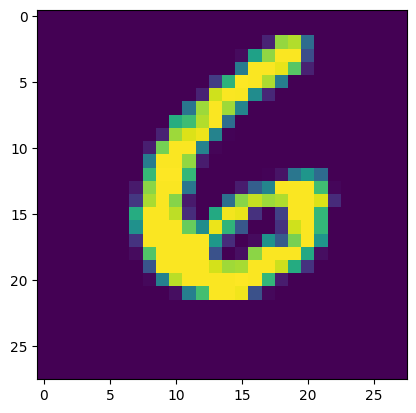

6


In [11]:
#displaying the image
plt.imshow(X_train[90])
plt.show()

#print corresponding img
print(Y_train[90])

In [13]:
#Image labels
print(Y_train.shape,Y_test.shape)

(60000,) (10000,)


In [15]:
#unique values in y_train
print(np.unique(Y_train))

#unique values in y_test
print(np.unique(Y_test))

[0 1 2 3 4 5 6 7 8 9]
[0 1 2 3 4 5 6 7 8 9]


we can use the label as such or we can apply one hot encoding

All the images have the same dimension in the dataset, if not we have to resize the images to common dimension

In [16]:
#scaling the values
X_train = X_train/255
X_test = X_test/255

In [17]:
#earlier 0-255 range now 0-1
print(X_train[10])

[[0.         0.         0.         0.         0.         0.
  0.         0.         0.         0.         0.         0.
  0.         0.         0.         0.         0.         0.
  0.         0.         0.         0.         0.         0.
  0.         0.         0.         0.        ]
 [0.         0.         0.         0.         0.         0.
  0.         0.         0.         0.         0.         0.
  0.         0.         0.         0.         0.         0.
  0.         0.         0.         0.         0.         0.
  0.         0.         0.         0.        ]
 [0.         0.         0.         0.         0.         0.
  0.         0.         0.         0.         0.         0.
  0.         0.         0.         0.         0.         0.
  0.         0.         0.         0.         0.         0.
  0.         0.         0.         0.        ]
 [0.         0.         0.         0.         0.         0.
  0.         0.         0.         0.         0.         0.
  0.         0.    

Building the neural network



In [18]:
#setting up the layers of the network
#flattening - instead of running 28 it will send only 1 row
model = keras.Sequential([
    keras.layers.Flatten(input_shape=(28,28)),
    keras.layers.Dense(50,activation='relu'),
    keras.layers.Dense(50,activation='relu'),
    keras.layers.Dense(10,activation='sigmoid')
])

/usr/local/lib/python3.12/dist-packages/keras/src/layers/reshaping/flatten.py:37: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


In [19]:
#compiling the model
model.compile(optimizer='Adam',
              loss='sparse_categorical_crossentropy',
              metrics=['accuracy'])

In [20]:
#training the neural network

model.fit(X_train,Y_train,epochs=10)

Epoch 1/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 3s 1ms/step - accuracy: 0.9114 - loss: 0.3008
Epoch 2/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 3s 1ms/step - accuracy: 0.9578 - loss: 0.1423
Epoch 3/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 3s 1ms/step - accuracy: 0.9679 - loss: 0.1052
Epoch 4/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 3s 2ms/step - accuracy: 0.9743 - loss: 0.0826
Epoch 5/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 3s 1ms/step - accuracy: 0.9791 - loss: 0.0676
Epoch 6/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 2s 1ms/step - accuracy: 0.9831 - loss: 0.0552
Epoch 7/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 3s 1ms/step - accuracy: 0.9860 - loss: 0.0469
Epoch 8/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 3s 2ms/step - accuracy: 0.9876 - loss: 0.0403
Epoch 9/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 3s 1ms/step - accuracy: 0.9889 - loss: 0.0348
Epoch 10/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 3s 1ms/step - accuracy: 0.9894 - loss: 0.0323


Training data accuracy = 98.9%

```
# This is formatted as code
```



In [21]:
#Accuracy on Test data
loss, accuracy = model.evaluate(X_test,Y_test)
print(accuracy)

313/313 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - accuracy: 0.9660 - loss: 0.1375
0.9660000205039978


Test data accuracy = 96.6%


In [22]:
print(X_test.shape)

(10000, 28, 28)


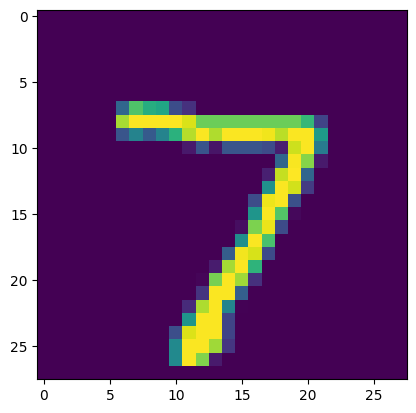

In [23]:
#first data point in X_Test
plt.imshow(X_test[0])
plt.show()

In [24]:
print(Y_test[0])

7


In [25]:
Y_pred =  model.predict(X_test)
print(Y_pred.shape)


313/313 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step
(10000, 10)


In [26]:
print(Y_pred[0])

[1.3741430e-06 4.5562672e-05 3.7565935e-04 1.6472457e-01 6.3755274e-06
 1.8637836e-03 5.5307057e-12 9.9971378e-01 4.0365155e-03 7.1497148e-01]


model.predict() gives the prediction probability of each class for that data point

In [27]:
#converting the prediction probabilities to class label
label_for_first_test_image = np.argmax(Y_pred[0])
print(label_for_first_test_image)

7


In [28]:
#converting the prediction probabilities to class label for all test data points
Y_pred_label = [np.argmax(i) for i in Y_pred]
print(Y_pred_label)

[np.int64(7), np.int64(2), np.int64(1), np.int64(0), np.int64(4), np.int64(1), np.int64(4), np.int64(9), np.int64(5), np.int64(9), np.int64(0), np.int64(6), np.int64(9), np.int64(0), np.int64(1), np.int64(5), np.int64(9), np.int64(7), np.int64(3), np.int64(4), np.int64(9), np.int64(6), np.int64(6), np.int64(5), np.int64(4), np.int64(0), np.int64(7), np.int64(4), np.int64(0), np.int64(1), np.int64(3), np.int64(1), np.int64(3), np.int64(4), np.int64(7), np.int64(2), np.int64(7), np.int64(1), np.int64(3), np.int64(1), np.int64(1), np.int64(7), np.int64(4), np.int64(2), np.int64(3), np.int64(5), np.int64(1), np.int64(2), np.int64(4), np.int64(4), np.int64(6), np.int64(3), np.int64(5), np.int64(5), np.int64(6), np.int64(0), np.int64(4), np.int64(1), np.int64(9), np.int64(5), np.int64(7), np.int64(8), np.int64(9), np.int64(3), np.int64(7), np.int64(4), np.int64(6), np.int64(4), np.int64(3), np.int64(0), np.int64(7), np.int64(0), np.int64(2), np.int64(9), np.int64(1), np.int64(7), np.int64(3)

Y_test = True label
Y_pred_labels = Predicted labels


Confusion matrix

In [29]:
conf_matx = confusion_matrix(Y_test,Y_pred_label)
print(conf_matx)

tf.Tensor(
[[ 944    0    4    1    2    1    2    1    1   24]
 [   0 1114    1    4    3    0    6    1    6    0]
 [   4    2  976   24    5    0    3    8    8    2]
 [   0    0    4  981    0    7    0    7    2    9]
 [   0    0    0    0  964    0    5    2    1   10]
 [   1    0    0   14    3  857    3    1    5    8]
 [   3    3    1    1    8   10  930    0    1    1]
 [   0    3    8    8    2    0    1  982    2   22]
 [   1    0    4   10    8    3    2    3  931   12]
 [   1    2    0    3   16    3    0    1    2  981]], shape=(10, 10), dtype=int32)


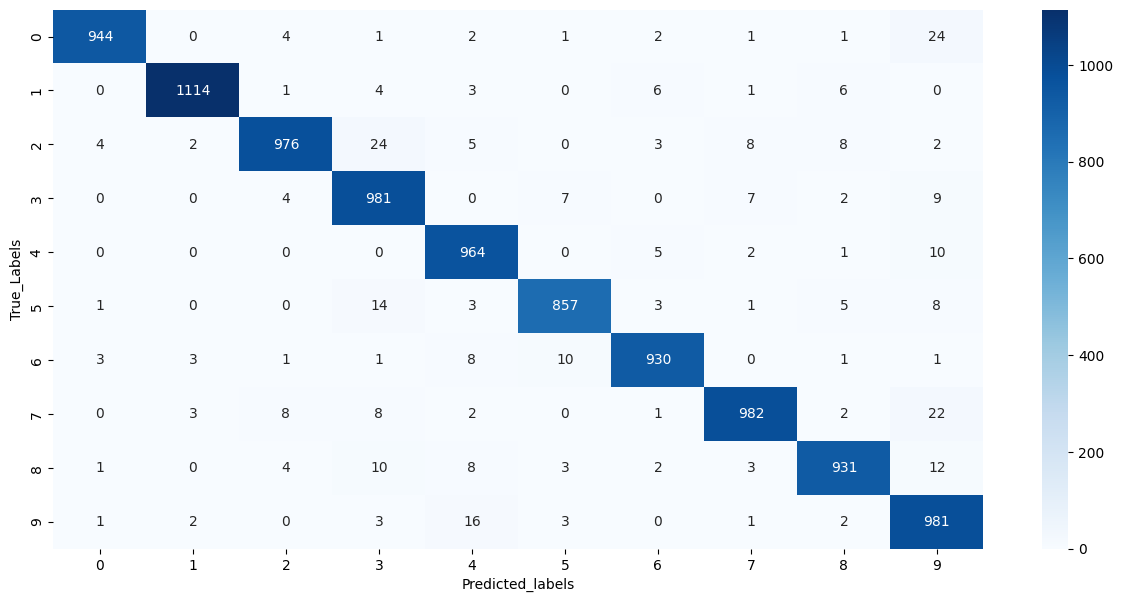

In [30]:
plt.figure(figsize=(15,7))
sns.heatmap(conf_matx,annot=True,fmt='d',cmap='Blues')
plt.ylabel("True_Labels")
plt.xlabel("Predicted_labels")
plt.show()

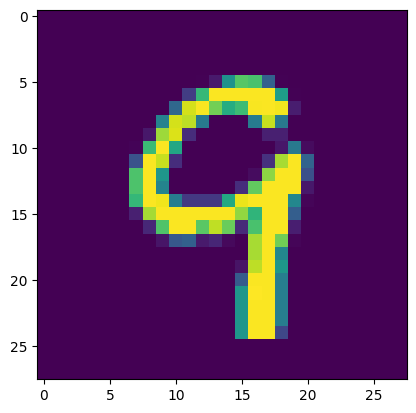

In [33]:
#Build a predictive system
input_image = X_test[150]
input_image = np.array(input_image)
plt.imshow(input_image)

Let's check the prediction for the `input_image`.

In [34]:
# Reshape the input image to add the batch dimension (1, 28, 28)
input_image_reshaped = np.array(input_image).reshape(1, 28, 28)

# Make prediction
prediction = model.predict(input_image_reshaped)

# Get the predicted label
predicted_label = np.argmax(prediction)

print(f"The predicted label for the input image is: {predicted_label}")

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 24ms/step
The predicted label for the input image is: 9


In [ ]:
#imge from external
input_image_2 = cv2.imread('')

cv2_imshow(input_image_2)

grayscale = cv2.cvtColor(input_image_2,cv2.COLOR_BGR2GRAY)

resized = cv2.resize(grayscale,(28,28))

resized = resized/255

reshaped = np.reshape(resized,[1,28,28])

prediction = model.predict(reshaped)


label = np.argmax(prediction)

print('The Handwritten Digit is recognized as:'label)
